# 03 Models Baseline

Этот ноутбук обучает **модели на каждом fold** и считает метрики качества:

1. **Ridge** — L2 регуляризация (аналог GBLUP)
2. **Lasso** — L1 регуляризация (отбор признаков)
3. **Elastic Net** — комбинация L1 + L2

Для каждой модели считаем: `corr` (корреляция), `rmse`, `mae`, `r2`.

**Для кого**: для тех, кто хочет увидеть, как разные модели работают на одних данных и какие показывают лучшие результаты.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

from gp_py.io import fn_load_genotype, fn_load_phenotype
from gp_py.cv import fn_cross_validation_preparation, fn_cross_validation_within_population
from gp_py.schema import MergedData

## 1. Подготовка данных

In [2]:
DATA_DIR = Path("../inst/exec_Rscript/input")

G = fn_load_genotype(str(DATA_DIR / "test_geno.Rds"))
list_pheno = fn_load_phenotype(str(DATA_DIR / "test_pheno.tsv"))

# Фильтруем genotype
from gp_py.io import fn_filter_genotype, fn_filter_phenotype, fn_merge_genotype_and_phenotype

Gf = fn_filter_genotype(G)
phf = fn_filter_phenotype(list_pheno)
merged = fn_merge_genotype_and_phenotype(Gf, phf)

# Оставляем только известные фенотипы для CV
known_mask = merged.y.notna()
merged_known = MergedData(
    G=merged.G.loc[known_mask].copy(),
    y=merged.y.loc[known_mask].copy(),
    pop=merged.pop.loc[known_mask].copy(),
    trait_name=merged.trait_name,
)

print(f"Размер данных для CV: {merged_known.G.shape}")
print(f"Популяции: {merged_known.pop.unique()}")

Размер данных для CV: (500, 1000)
Популяции: <ArrowStringArray>
['pop_1', 'pop_2', 'pop_3']
Length: 3, dtype: str


## 2. Запуск CV с несколькими моделями

In [8]:
# Параметры
N_FOLDS = 3
N_REPS = 2
MODELS = ("ridge", "lasso", "elastic_net")

print("Запускаем кросс-валидацию...")
cv_results = fn_cross_validation_within_population(
    merged_known,
    n_folds=N_FOLDS,
    n_reps=N_REPS,
    vec_models_to_test=MODELS,
    bool_parallel=False,  # для наглядности.Sequential
    bayes_backend="native",  # без R
    verbose=True
)

print("Готово!")

Запускаем кросс-валидацию...


/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.409e-02, tolerance: 6.115e-02
  model = cd_fast.enet_coordinate_descent(
/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.683e-02, tolerance: 6.162e-02
  model = cd_fast.enet_coordinate_descent(
/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase 

Готово!


## 3. Результаты CV — сводная таблица метрик

In [4]:
metrics_df = cv_results["METRICS_WITHIN_POP"]
print("=== Метрики по всем fold-ам ===")
print(metrics_df.head(10).to_string())

=== Метрики по всем fold-ам ===
   rep  fold        model       mbe       mae      rmse        r2      corr
0    1     1        ridge  0.027636  0.933772  1.188962  0.274470  0.533943
1    1     1        lasso -0.053214  0.857058  1.109801  0.367865  0.608692
2    1     1  elastic_net -0.051120  0.856749  1.107975  0.369944  0.609840
3    1     2        ridge -0.047608  1.088535  1.332902  0.140724  0.418197
4    1     2        lasso -0.073135  1.002898  1.256416  0.236511  0.504915
5    1     2  elastic_net -0.070482  1.001846  1.256338  0.236605  0.503379
6    1     3        ridge -0.026993  0.991286  1.243493  0.295124  0.543977
7    1     3        lasso -0.007436  0.892957  1.143653  0.403769  0.652793
8    1     3  elastic_net -0.008068  0.895421  1.144481  0.402905  0.650386
9    2     1        ridge  0.315935  0.961899  1.197825  0.262616  0.566361


## 4. Агрегированные метрики по моделям

In [5]:
# Среднее и std по моделям
agg = metrics_df.groupby("model").agg({
    "corr": ["mean", "std"],
    "rmse": ["mean", "std"],
    "mae": ["mean", "std"],
    "r2": ["mean", "std"]
}).round(4)

print("=== Среднее ± std метрик по моделям ===")
print(agg.to_string())

=== Среднее ± std метрик по моделям ===
               corr            rmse             mae              r2        
               mean     std    mean     std    mean     std    mean     std
model                                                                      
elastic_net  0.6040  0.0561  1.1593  0.0769  0.9123  0.0668  0.3459  0.0614
lasso        0.6053  0.0560  1.1583  0.0757  0.9106  0.0661  0.3470  0.0613
ridge        0.5040  0.0631  1.2560  0.0809  1.0059  0.0706  0.2328  0.0606


## 5. Визуализация: сравнение моделей по корреляции

/tmp/ipykernel_62851/1787638210.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_for_box, labels=models, patch_artist=True)


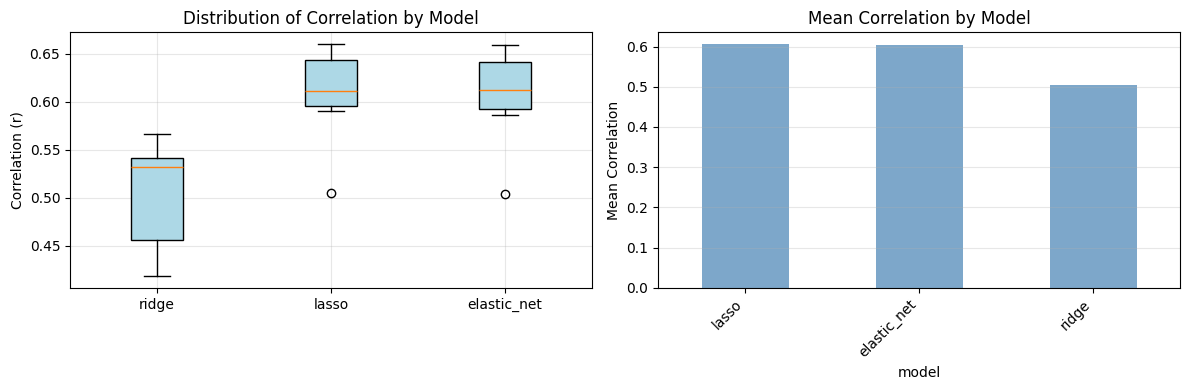

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot корреляций
ax1 = axes[0]
models = metrics_df["model"].unique()
data_for_box = [metrics_df[metrics_df["model"] == m]["corr"].values for m in models]
bp = ax1.boxplot(data_for_box, labels=models, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")
ax1.set_ylabel("Correlation (r)")
ax1.set_title("Distribution of Correlation by Model")
ax1.grid(True, alpha=0.3)

# Barplot средней корреляции
ax2 = axes[1]
mean_corr = metrics_df.groupby("model")["corr"].mean().sort_values(ascending=False)
mean_corr.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.7)
ax2.set_ylabel("Mean Correlation")
ax2.set_title("Mean Correlation by Model")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Лучшая модель

In [7]:
best_model = metrics_df.groupby("model")["corr"].mean().idxmax()
best_corr = metrics_df.groupby("model")["corr"].mean().max()

print("=== Лучшая модель по средней корреляции ===")
print(f"  Модель: {best_model}")
print(f"  Средняя корреляция: {best_corr:.4f}")

=== Лучшая модель по средней корреляции ===
  Модель: lasso
  Средняя корреляция: 0.6053


## Итог

- Мы обучили 3 модели (Ridge, Lasso, Elastic Net) на 3 folds × 2 reps = 6 итераций
- Для каждой модели получили метрики: corr, rmse, mae, r2
- Лучшая модель определяется по средней корреляции на validation-фолдах
- Эта лучшая модель будет использоваться для предсказания пропущенных фенотипов

**Следующий шаг**: перейти к ноутбуку `04_missing_phenotype_prediction`, чтобы увидеть, как лучшая модель предсказывает пропущенные значения.